# EVASPA Evapotranspiration processing

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pprint import pprint
from matplotlib.colors import ListedColormap

In [81]:
from evaspa.configuration import ParamsConfig
import evaspa.filter as filter
import evaspa.ef as ef
import evaspa.seb as seb

### Common

In [5]:
if os.environ["EVASPA_TEST_DATA_PATH"] is None:
    raise Exception("Variable EVASPA_TEST_DATA_PATH must be set")

In [39]:
def plot_rgb(data: xr.Dataset,bands:list[str]=["red","green","blue"]):
    rgb = xr.DataArray(
            np.dstack((data[bands[0]].data, data[bands[1]].data, data[bands[2]].data)),
            data.coords.assign(band=["r", "g", "b"]),
            dict(data.sizes, band= 3),
        )
    rgb.plot.imshow(  # type: ignore
            rgb="band",
            vmin=rgb.quantile(0.01),
            vmax=rgb.quantile(0.99),
        )
    plt.title("RGB")

def plot_band(data:xr.Dataset,band:str):
    data[band].plot.imshow(  # type: ignore
            vmin=data[band].quantile(0.01),
            vmax=data[band].quantile(0.99),
        )

def plot_mask(data:xr.Dataset,mask:str,invert=False):
    cmap = [(0.0, 0.0, 0.0, 0.0)]
    if len(np.unique(data[mask].data)) > 1:
        cmap = [(1.0, 0.0, 0.0, 1.0), (0.0, 0.0, 0.0, 0.0)]
    if invert:
        cmap = cmap[::-1]
    valid_cmap = ListedColormap(cmap)
    data[mask].plot(cmap=valid_cmap, add_colorbar=False)


def plot(
    data: xr.Dataset, var_name: str = None, model: efm.EFModel = None, save: bool = False
):
    """
    Plot
    """
    # dimensions
    # gridspec inside gridspec
    fig = plt.figure(constrained_layout=True, figsize=(4, 3))

    ax = plt.gca()

    if var_name is None and model is None:
        raise ValueError("Provide either var_name or model")
    lst = data["lst"].data

    if var_name is not None:
        var = data[var_name].data
        # plot all points
        ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)

    # plot edges
    elif model is not None:
        var_name = model.var
        var = data[model.var].data
        # plot all points
        ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)
        # edges coordinates
        var_max = np.round(np.ceil(np.nanmax(var) * 10) / 10, decimals=1)
        var_min = np.round(np.floor(np.nanmin(var) * 10) / 10, decimals=1)

        var_arr = np.linspace(var_min, var_max, num=20)
        tw_arr = model.twet(var_arr)
        td_arr = model.tdry(var_arr)

        ax.plot(
            var_arr,
            td_arr,
            color="tab:red",
            linewidth=3,
            label="dry edge",
            zorder=1,
        )
        ax.plot(
            var_arr,
            tw_arr,
            color="tab:blue",
            linewidth=3,
            label="wet edge",
            zorder=1,
        )

    # Labels
    ax.set_xlabel(var_name)
    ax.set_ylabel("Land Surface Temperature K")

    # title
    ax.set_title("Evaporative fraction method", fontsize=12)

    # savefig
    if save:
        destfile = "ef.png"
        fig.savefig(destfile)

    plt.show()




### Input

In [7]:
import sys
sys.path.append("..")
from tests.test_seb import setup_data
import numpy.typing as npt

In [8]:
def extract_bits(arr:npt.ArrayLike, pos: int, mask: str = "1"):
    # Filter nan values
    assert pos >= 0
    array = np.array(arr)
    res = np.zeros_like(array)
    res[~np.isnan(array)] = np.isin(
        (array[~np.isnan(array)].astype(int) >> pos) & int("1" * len(mask), 2),
        int(mask,2),
    )
    return res.astype(bool)

#### Data

In [60]:
data = setup_data(nb=2)
#create cloud
data["cloud"] = xr.where(data["valid"],0,1)


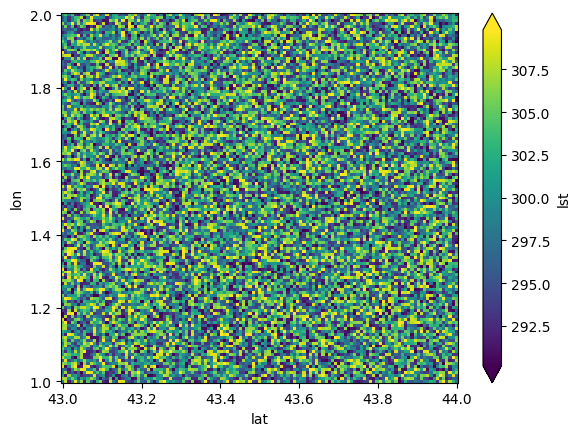

In [61]:
plot_band(data, band="lst")

#### Configuration

In [62]:
params = {
        "filtering":{
            "cloud": "cloud"
        },
        "check_variability":{
            "threshold": 0.02
        },
        "efconfig":{
            "models": "default_evaspa",
            "options":{
                "selection": False,
                "merging": "mean"
            }
        }
}

## Run step by step 

Validate parameters config

In [63]:
# Validate parameters config
params_config = ParamsConfig.model_validate(params)

In [ ]:
params_config

ParamsConfig(filtering={'cloud': 'cloud'}, check_variability={'threshold': 0.02}, efconfig=EFConfig(models=[EFModelConfig(name='model1', dry_edge=EdgeConfig(type='LinearEdge', config={'interval_type': 'size', 'interval_nb': 20, 'percentile': [98, 100], 'selection': 'median'}), wet_edge=EdgeConfig(type='LinearEdge', config={'interval_type': 'size', 'interval_nb': 20, 'percentile': [0, 2], 'selection': 'median'}), var='albedo'), EFModelConfig(name='model2', dry_edge=EdgeConfig(type='LinearEdge', config={'interval_type': 'density', 'interval_nb': 20, 'percentile': [95, 100], 'selection': 'median'}), wet_edge=EdgeConfig(type='FlatEdge', config={'selection': 'min'}), var='lai')], options=EFOptionsConfig(selection=False, merging=<MergeMethod.MEAN: 'mean'>, keep=True)))

In [83]:
pprint(params_config.model_dump(),sort_dicts=False)

{'filtering': {'cloud': 'cloud'},
 'check_variability': {'threshold': 0.02},
 'efconfig': {'models': [{'name': 'model1',
                          'dry_edge': {'type': 'LinearEdge',
                                       'config': {'interval_type': 'size',
                                                  'interval_nb': 20,
                                                  'percentile': [98, 100],
                                                  'selection': 'median'}},
                          'wet_edge': {'type': 'LinearEdge',
                                       'config': {'interval_type': 'size',
                                                  'interval_nb': 20,
                                                  'percentile': [0, 2],
                                                  'selection': 'median'}},
                          'var': 'albedo'},
                         {'name': 'model2',
                          'dry_edge': {'type': 'LinearEdge',
                       

Filter

In [65]:
# Filter data
data["valid"] = filter.determine_valid_pixels(data, **params_config.filtering)

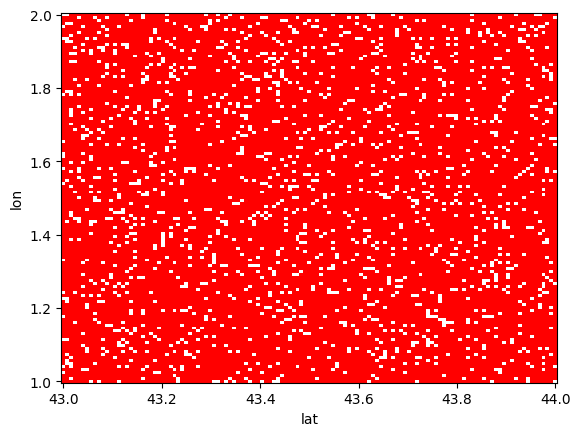

In [66]:
plot_mask(data=data, mask="valid", invert=True)

Check variability

In [67]:
ef.check_variability(data["lst"],mask=data["valid"],**params_config.check_variability)

True

Compute EF

In [75]:
models, options = ef.initialize(params_config.efconfig.model_dump())

In [76]:
ef_xr = ef.run(
    models, data, mask="valid", **params_config.efconfig.options.model_dump()
)

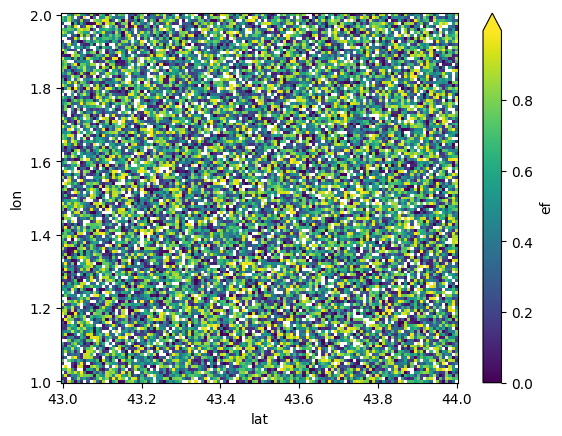

In [77]:
plot_band(ef_xr,band="ef")

Compute LE

In [78]:
rn_xr = seb.create_net_radiation(data)

In [79]:
g_xr = seb.create_gflux(data, rn_xr)

In [80]:
le_xr = seb.compute_le(ef_xr,rn_xr,g_xr)

model1
model2
ef
